# Retail Sales EDA

**OIBSIP Data Analytics Internship — Task 1**

**Goal:** Explore a retail sales dataset and find simple, useful business insights.

This notebook follows a beginner-friendly workflow:
1. Load the data
2. Check the dataset
3. Clean basic data issues
4. Explore sales trends
5. Compare customer demographics
6. Compare product categories
7. Check correlations
8. Write observations and recommendations

## 1. Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## 2. Load the dataset

In [2]:
df = pd.read_csv("data/retail_sales_dataset.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


## 3. Basic information

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data types:
Transaction ID       int64
Date                object
Customer ID         object
Gender              object
Age                  int64
Product Category    object
Quantity             int64
Price per Unit       int64
Total Amount         int64
dtype: object

Missing values:
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


## 4. Prepare the date column

In [4]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print("Date range:")
print(df["Date"].min(), "to", df["Date"].max())

Date range:
2023-01-01 00:00:00 to 2024-01-01 00:00:00


## 5. Monthly sales trend

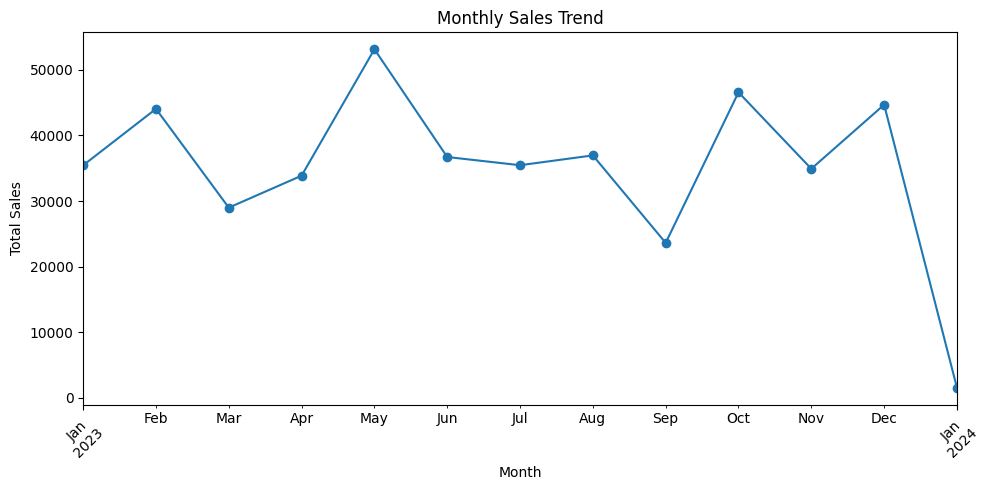

In [5]:
monthly_sales = df.groupby(df["Date"].dt.to_period("M"))["Total Amount"].sum()

plt.figure(figsize=(10, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Observation

The monthly chart shows how total sales changed over time. Peaks can indicate stronger sales periods, while lower months may need further investigation.

## 6. Quarterly sales trend

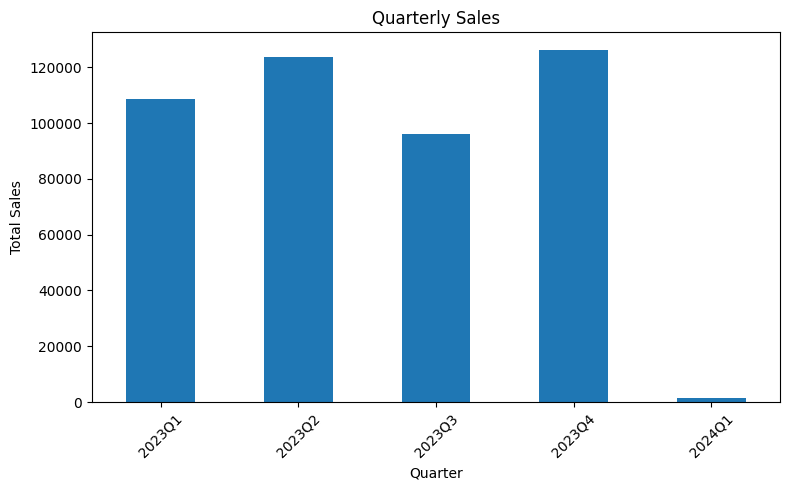

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64


In [6]:
quarterly_sales = df.groupby(df["Date"].dt.to_period("Q"))["Total Amount"].sum()

plt.figure(figsize=(8, 5))
quarterly_sales.plot(kind="bar")
plt.title("Quarterly Sales")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(quarterly_sales)

## 7. Gender distribution

Gender
Female    510
Male      490
Name: count, dtype: int64


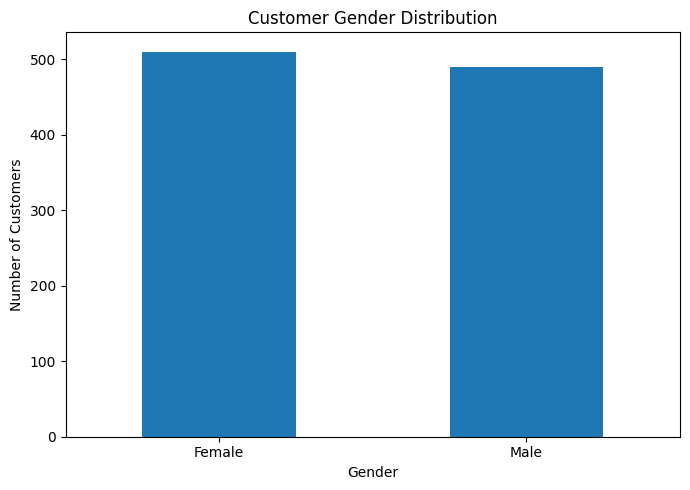

In [7]:
gender_count = df["Gender"].value_counts()
print(gender_count)

plt.figure(figsize=(7, 5))
gender_count.plot(kind="bar")
plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Age group distribution

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56+      195
Name: count, dtype: int64


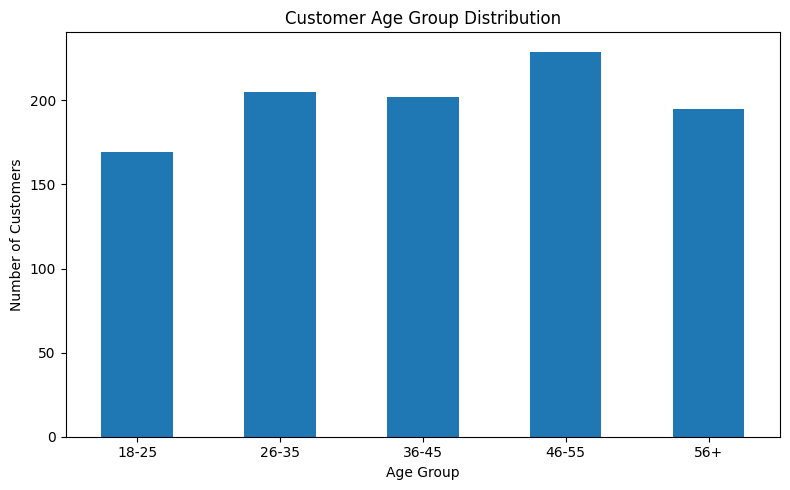

In [8]:
bins = [17, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]

df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

age_group = df["Age Group"].value_counts().sort_index()
print(age_group)

plt.figure(figsize=(8, 5))
age_group.plot(kind="bar")
plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Revenue by product category

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64


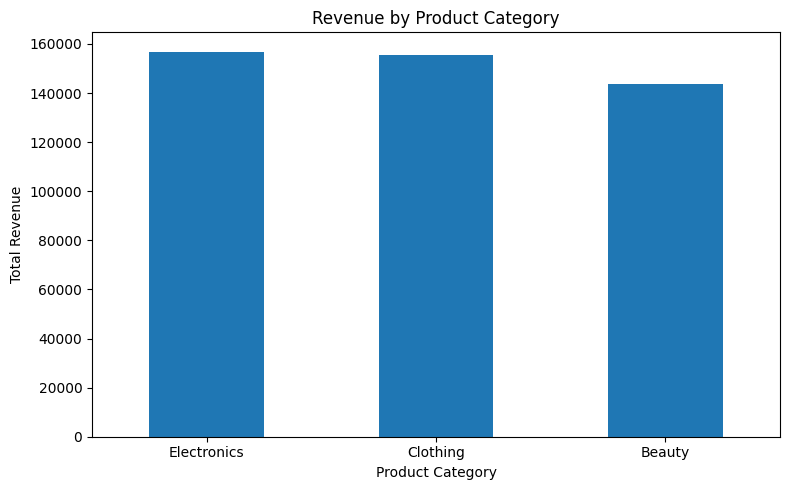

In [9]:
category_revenue = df.groupby("Product Category")["Total Amount"].sum().sort_values(ascending=False)

print(category_revenue)

plt.figure(figsize=(8, 5))
category_revenue.plot(kind="bar")
plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation

Electronics is the highest-revenue category in this dataset, while Beauty contributes the least. Clothing is very close to Electronics, so the top two categories have similar revenue performance.

## 10. Quantity sold by category

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64


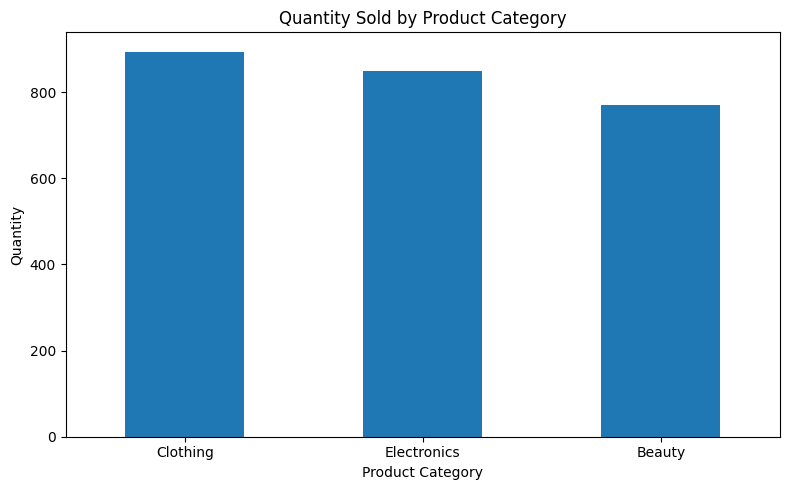

In [10]:
quantity_by_category = df.groupby("Product Category")["Quantity"].sum().sort_values(ascending=False)

print(quantity_by_category)

plt.figure(figsize=(8, 5))
quantity_by_category.plot(kind="bar")
plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Correlation between numerical variables

                     Age  Quantity  Price per Unit  Total Amount
Age             1.000000 -0.023737       -0.038423     -0.060568
Quantity       -0.023737  1.000000        0.017501      0.373707
Price per Unit -0.038423  0.017501        1.000000      0.851925
Total Amount   -0.060568  0.373707        0.851925      1.000000


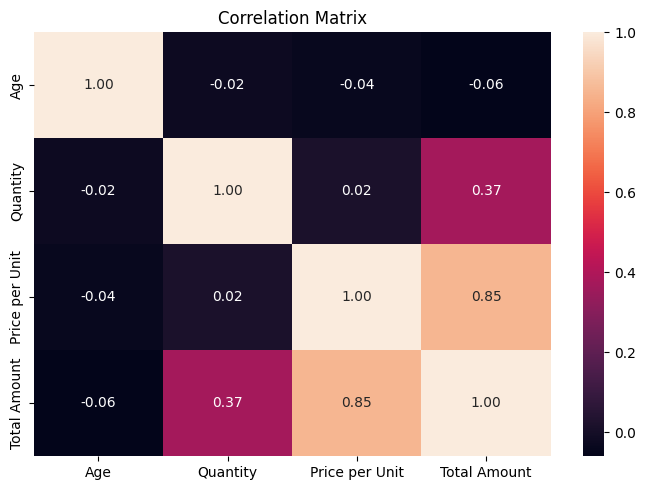

In [11]:
numeric_cols = ["Age", "Quantity", "Price per Unit", "Total Amount"]
correlation = df[numeric_cols].corr()

print(correlation)

plt.figure(figsize=(7, 5))
sns.heatmap(correlation, annot=True, fmt=".2f")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 12. Additional analysis: average order value by gender

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64


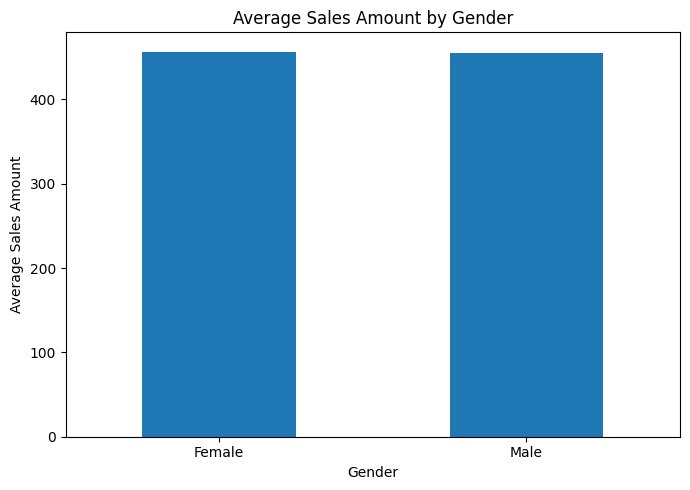

In [12]:
avg_by_gender = df.groupby("Gender")["Total Amount"].mean().sort_values(ascending=False)
print(avg_by_gender)

plt.figure(figsize=(7, 5))
avg_by_gender.plot(kind="bar")
plt.title("Average Sales Amount by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Sales Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 13. Final business observations

- Sales performance changes across months and quarters, so seasonal patterns should be monitored.
- Electronics is the leading revenue category in this dataset.
- Clothing is also a strong contributor and is close to Electronics in total revenue.
- Beauty has the lowest total revenue among the three main categories.
- The customer base contains a mix of age groups, so marketing should not target only one age segment.
- Gender distribution is relatively balanced.
- The correlation matrix helps identify whether quantity, price and total amount move together.

## 14. Business recommendations

1. Focus promotional campaigns on strong-performing categories while testing ways to improve lower-performing categories.
2. Monitor monthly and quarterly sales to identify high-performing periods.
3. Use age and gender insights to create more relevant marketing campaigns.
4. Investigate high-value orders to understand what products or quantities are driving revenue.
5. Repeat this analysis regularly so business decisions are based on current data.

**Note:** The supplied dataset does not contain an individual product-name column, so the analysis focuses on product categories rather than ranking individual products.

## 15. Conclusion

This EDA shows a complete beginner-level analytics workflow: understanding the data, checking quality, visualising trends, comparing customer groups, analysing categories and converting the findings into business recommendations.